In [2]:
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_platform_name", "gpu")
print(jax.local_devices()[0].device_kind)
from jax import numpy as np, random as jr, tree as jtu
import os


import zodiax as zdx
from zodiax.optimisation import sgd, adam
import dLux.utils as dlu

from amigo.fitting import Trainer
import dorito


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


/home/max/miniforge3/envs/nuke/lib/python3.13/site-packages/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [4]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/GTO1242/")

load_dict = lambda x: np.load(x, allow_pickle=True).item()
cal_vis_outputs = load_dict(os.path.join(output_path, "cal_vis_PDS70.npy"))

print(cal_vis_outputs.keys())

dict_keys(['F380M', 'F430M', 'F480M'])


In [16]:
from scipy.ndimage import binary_dilation


class MCAOIFit(dorito.model_fits.ResolvedOIFit):

    def initialise_params(self, model, distribution, contrast=0.949):

        params = {}  # Initialise an empty dictionary for parameters

        # resolved component distributino
        distribution = (distribution.flatten())[~model.moat]
        distribution *= (
            1 - contrast
        ) / distribution.sum()  # normalise the distribution

        log_dist = np.log10(distribution)
        params["log_dist"] = self.get_key("log_dist"), log_dist

        # the star component
        params["contrast"] = self.get_key("contrast"), np.array(contrast)

        # Fourier normalisation (not to be optimised)
        params["base_uv"] = self.get_key("base_uv"), self.get_base_uv(
            model, distribution.shape[0]
        )
        params
        return params

    def get_key(self, param):

        match param:
            case "contrast":
                return self.filter

        return super().get_key(param)

    def map_param(self, param):

        # Map the appropriate parameter to the correct key
        if param in ["log_dist", "base_uv", "contrast"]:
            return f"{param}.{self.get_key(param)}"

        # Else its global
        return param

    def __call__(self, model, rotate=False):
        return super().__call__(model, rotate=rotate)


class MCADiscoModel(dorito.models.ResolvedDiscoModel):

    size: int = None
    moat: np.ndarray = None  # Placeholder for the moat attribute
    star: np.ndarray = None  # Placeholder for the star attribute

    def __init__(
        self,
        ois: list,
        distribution: np.ndarray,
        uv_npixels: int,
        uv_pscale: float,
        oversample: float = 1.0,
        psf_pixel_scale: float = 0.065524085,  # arcsec/pixel
        moat_width: int = 3,
    ):

        dist_shape = distribution.shape
        zeros = np.zeros(dist_shape).flatten()
        star = zeros.at[zeros.size // 2].set(True)

        moat_mask = binary_dilation(
            star.reshape(dist_shape), iterations=moat_width
        ).flatten()
        # Precompute safe indices for use in JIT-compiled code
        self.moat = np.where(~moat_mask)[0]  # shape (N,)

        self.star = star
        self.size = dist_shape[0]

        super().__init__(
            ois,
            distribution,
            uv_npixels,
            uv_pscale,
            oversample,
            psf_pixel_scale,
        )

    def get_distribution(self, exposure, rotate=False, with_star=True):
        """
        Get the distribution from the exposure.

        Args:
            exposure: The exposure object containing the distribution key.
        Returns:
            Array: The intensity distribution of the source.
        """

        zeros = np.zeros(self.size * self.size)
        values = 10 ** self.params["log_dist"][exposure.get_key("log_dist")]
        contrast = self.params["contrast"][exposure.get_key("contrast")]

        resolved_component = (
            zeros.at[self.moat].set(values).reshape((self.size, self.size))
        )

        if with_star:
            star_component = contrast * self.star.reshape((self.size, self.size))
            distribution = resolved_component + star_component
        else:
            distribution = resolved_component

        if rotate:
            distribution = exposure.rotate(distribution)

        return distribution

In [17]:
optics_diameter = 6.603464  # JWST aperture diameter in meters
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)

ois = [MCAOIFit(oi_data, key, filter=key) for key, oi_data in cal_vis_outputs.items()]
# ois = [ois[-1]]
for oi in ois:
    print(oi.key)

s = 91
distribution = np.ones((s, s))

model = MCADiscoModel(
    ois,
    distribution,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    oversample=3.0,
    moat_width=2,
)

# # Initialise at the mean dirty image
# otf = np.load("files/otf_support.npy")

# params = {"log_dist": {}, "base_uv": model.params["base_uv"]}
# hypot = lambda x: np.sqrt(np.array([_x**2 for _x in x]).sum(0))
# for filt in ["F380M", "F430M", "F480M"]:
#     dirty_imgs = [
#         oi.dirty_image(model, rotate=False, otf_support=otf)
#         for oi in ois
#         if oi.filter == filt
#     ]

#     if dirty_imgs == []:
#         print(f"No dirty images for filter {filt}, skipping initialisation.")
#         continue
#     mean_dirty = hypot(dirty_imgs)
#     init_dist = np.log10(mean_dirty / mean_dirty.sum() + 1e-16)
#     for oi in ois:
#         if oi.filter == filt:
#             params["log_dist"][oi.get_key("log_dist")] = init_dist

# model = model.set("params", params)

F380M
F430M
F480M


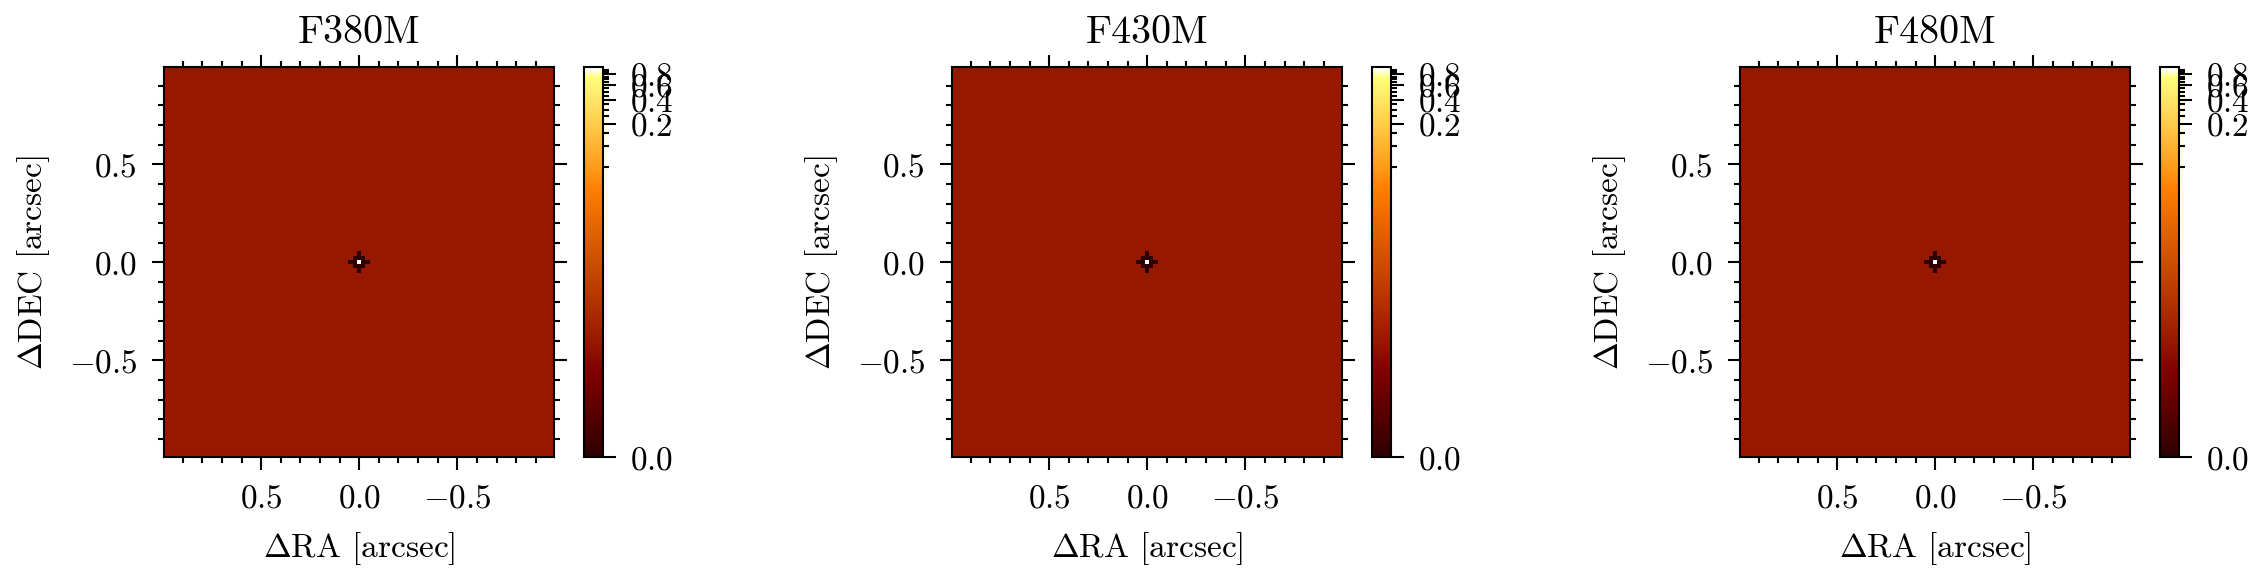

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(8, 2))

for idx, oi in enumerate(ois):

    init_dist = model.get_distribution(oi)

    c0 = dorito.plotting.plot_result(
        ax[idx],
        init_dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.1,
    )
    fig.colorbar(c0, ax=ax[idx])
    ax[idx].set(title=oi.filter)

plt.tight_layout()
plt.show()

In [19]:
def normalise_distribution(model_params, args):
    params = model_params.params

    for filt in params["log_dist"].keys():

        log_dist = params["log_dist"][filt]
        contrast = params["contrast"][filt]

        dist = 10**log_dist

        # normalising the distribution
        params["log_dist"][filt] = np.log10(dist * (1 - contrast) / dist.sum())

    return model_params.set("params", params), args


def looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.3e}")


def phase_centre(model, oi):

    distribution = model.get_distribution(oi)

    # Tip/Tilt vectors (ramp in u,v)
    mu = oi.u / np.linalg.norm(oi.u)
    mv = oi.v / np.linalg.norm(oi.v)

    # to log visibilities
    cvis = oi.to_cvis(model, distribution)
    phase = np.angle(cvis)

    # calculating the phase centre of the distribution
    return np.hypot(np.dot(mu, phase), np.dot(mv, phase))


def centered_loss_fn(model, exposure, args, width=1e-3):
    posterior = dorito.stats.regularised_loss_fn(model, exposure, args)[0]

    # phase centre prior
    centre = phase_centre(model, exposure)
    posterior += -jax.scipy.stats.norm.logpdf(centre, loc=0.0, scale=width)

    return posterior, ()

In [20]:
def ME(model, exposure):
    return dorito.stats.ME_loss(model.get_distribution(exposure, with_star=False))

In [24]:
n_epoch = 2000
config = {
    # "log_dist": adam(2e-2, 0, (5000, 0.1)),
    "log_dist": adam(5e-4, 0),
    "contrast": sgd(1e-9, 1000),
    # "log_dist": adam(5e-3, 0),
}
args = {
    "reg_dict": {
        "ME": (2e2, ME),
    }
}

trainer = Trainer(
    # loss_fn=centered_loss_fn,
    loss_fn=dorito.stats.regularised_loss_fn,
    norm_fn=normalise_distribution,
    looper_fn=looper,
)

trainer = trainer.update_fishers(
    model=model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
)

0it [00:00, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: -839.58
Compiling Loss function...
Compiling update function...
Estimated run time: 0:51:42
Full Time: 0:00:37
Final Loss: -3,392.38


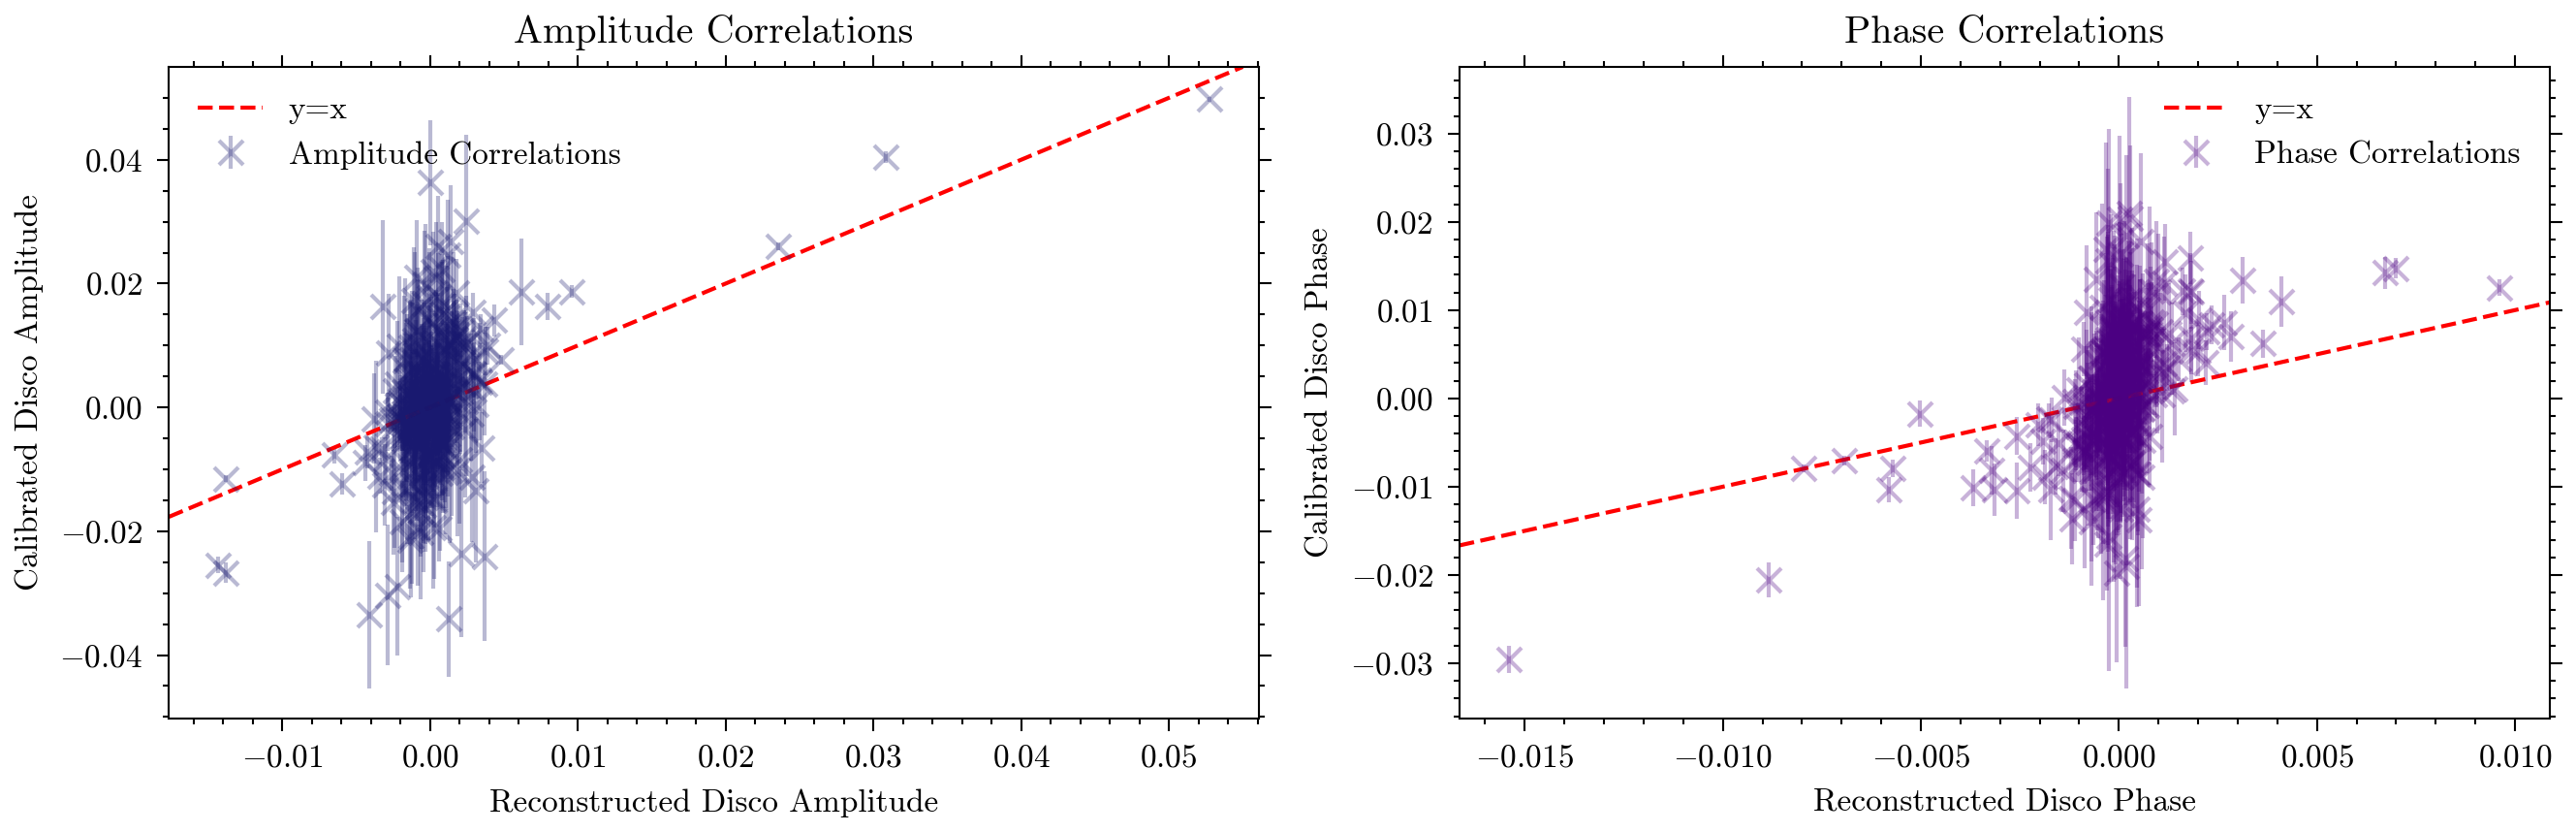

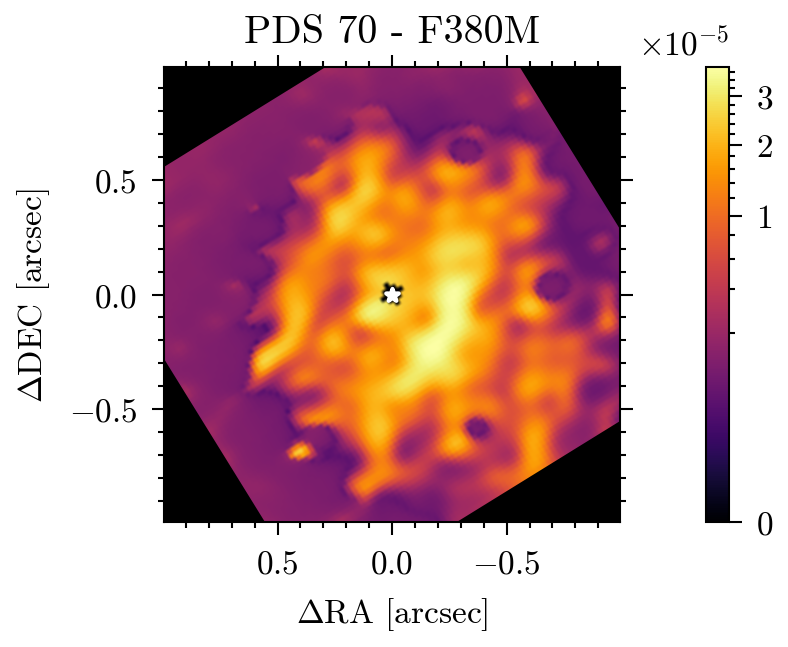

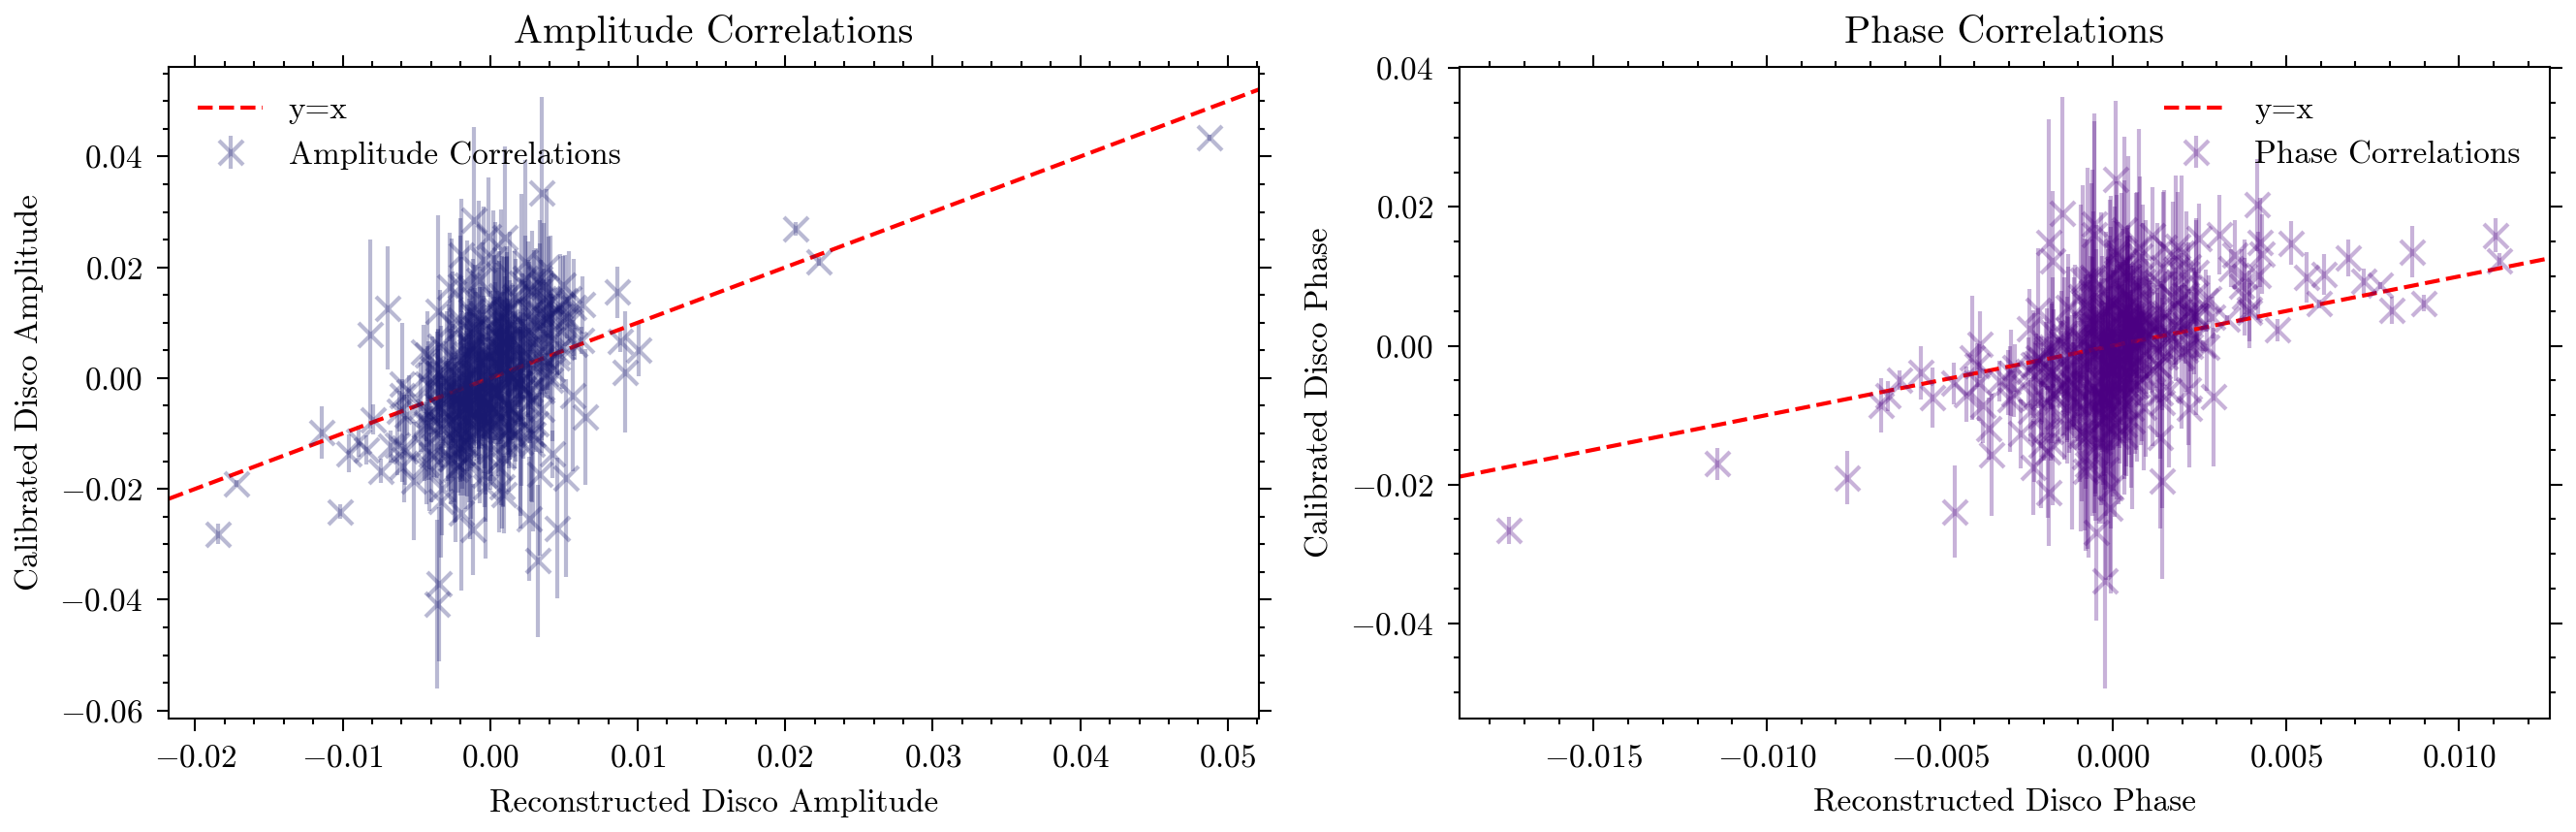

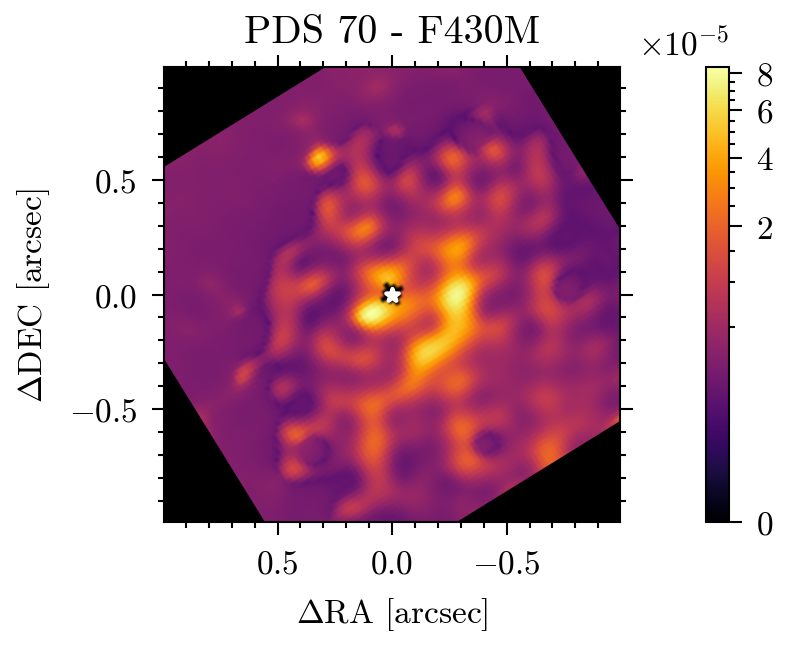

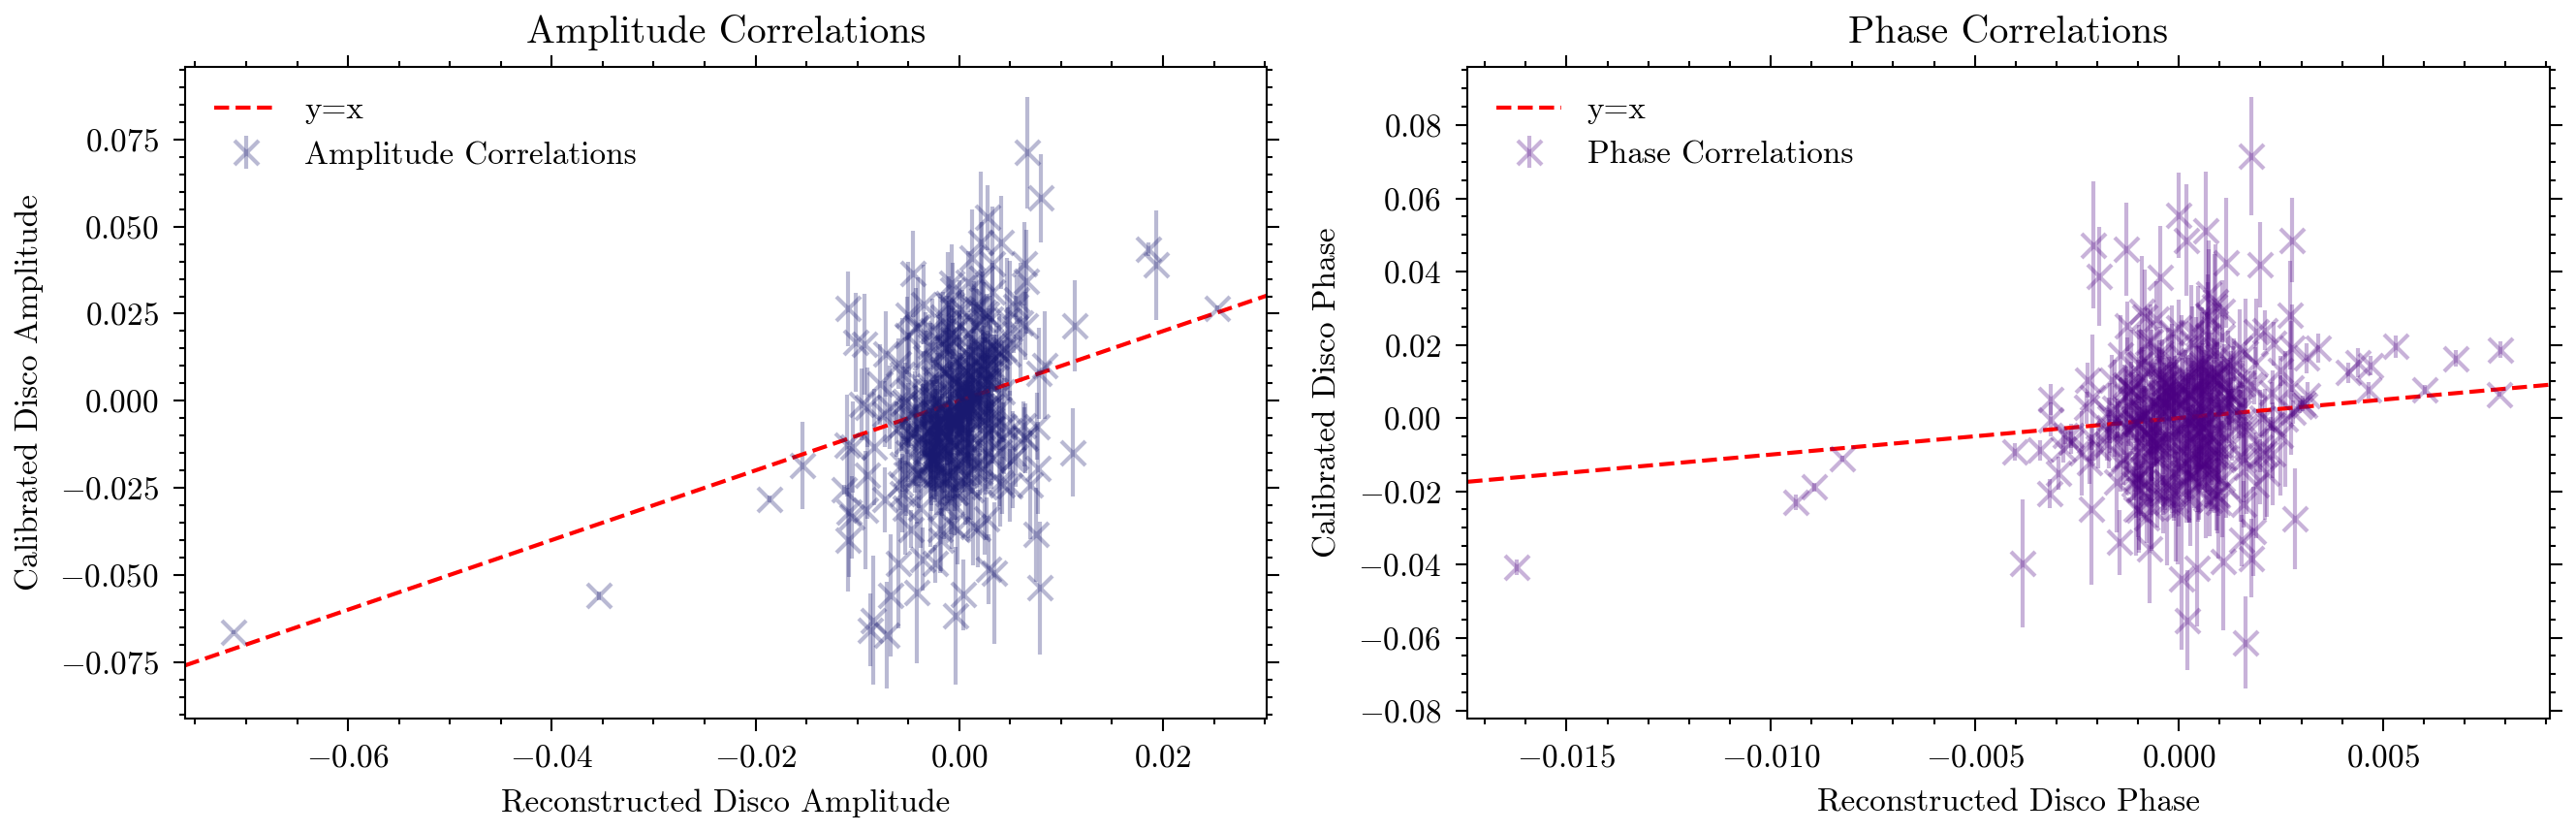

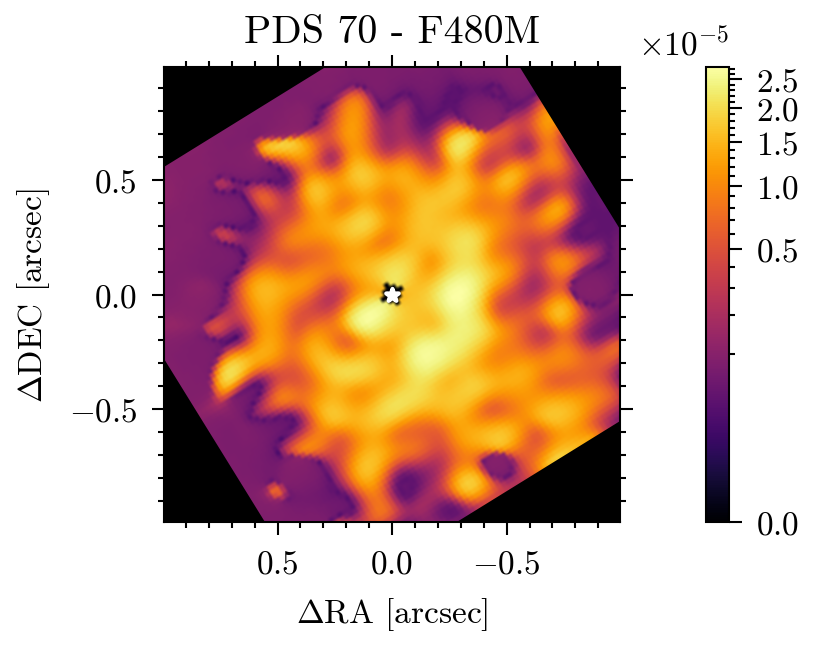

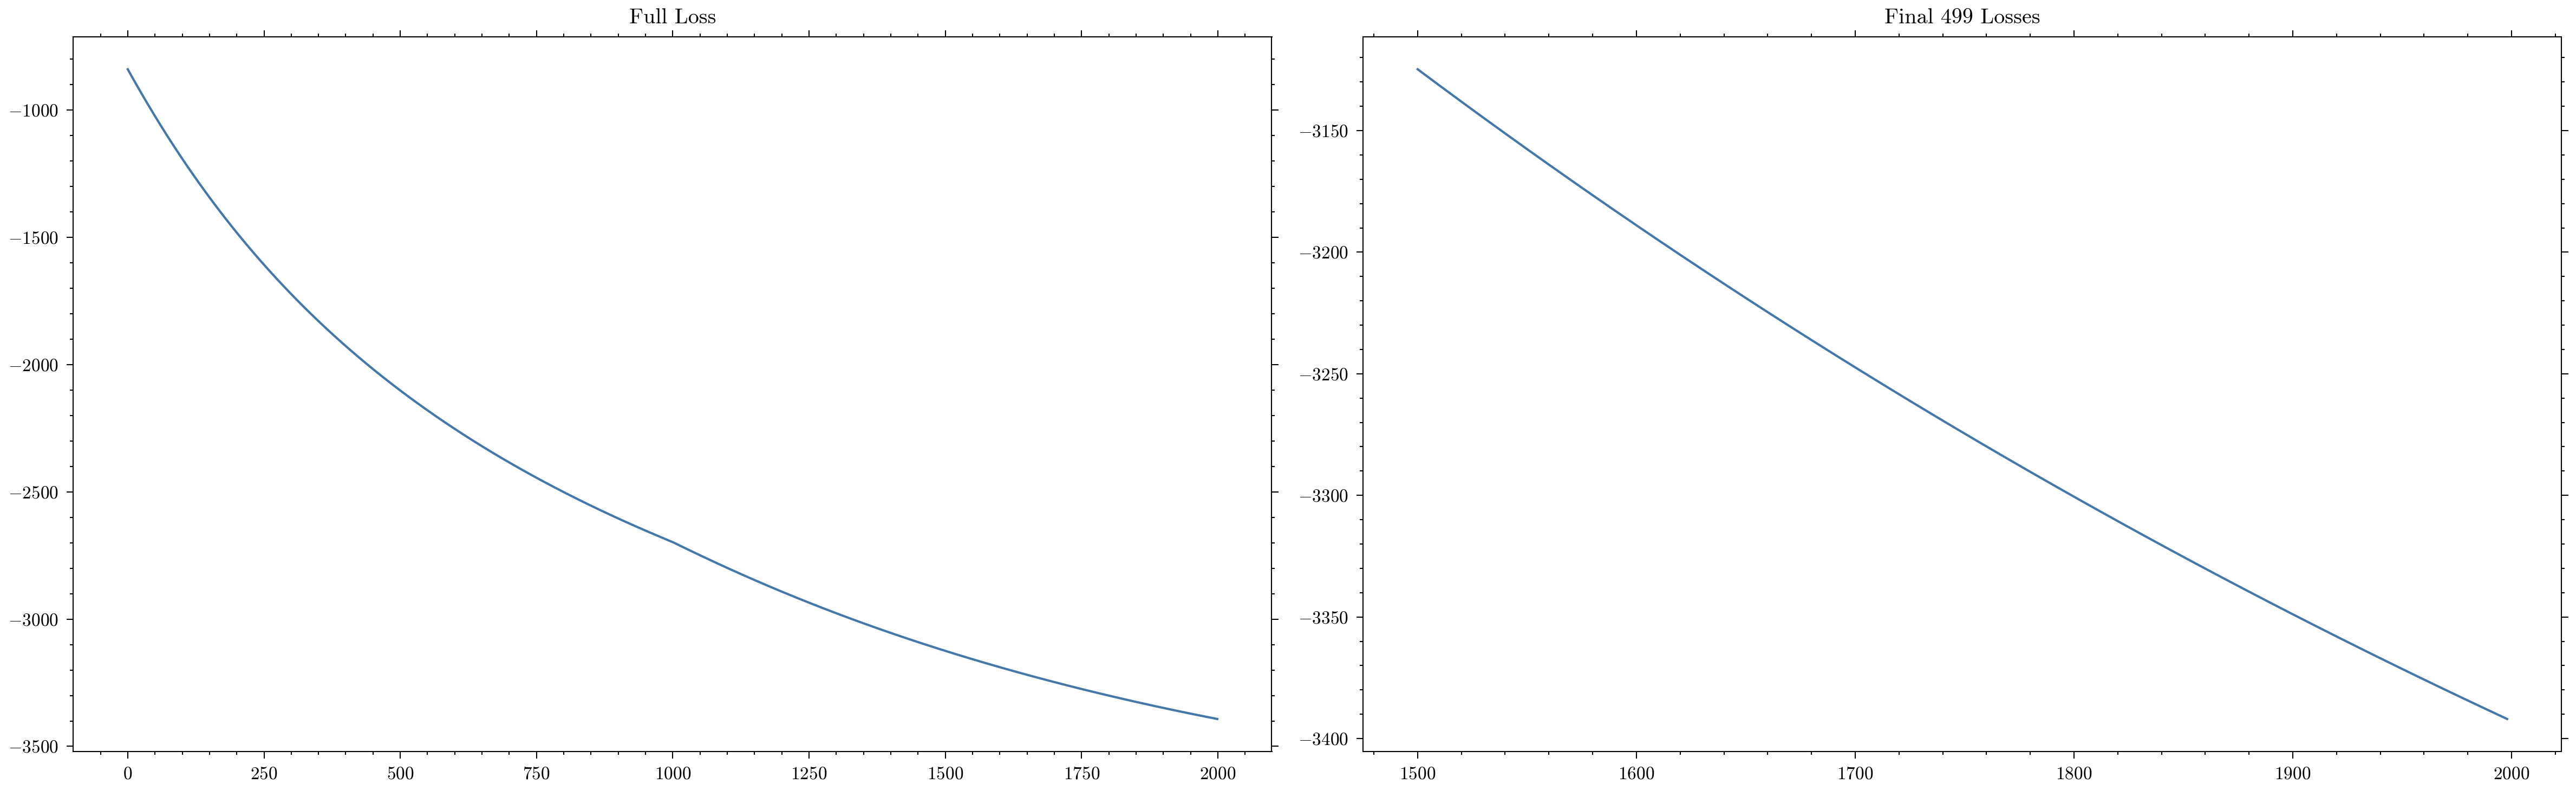

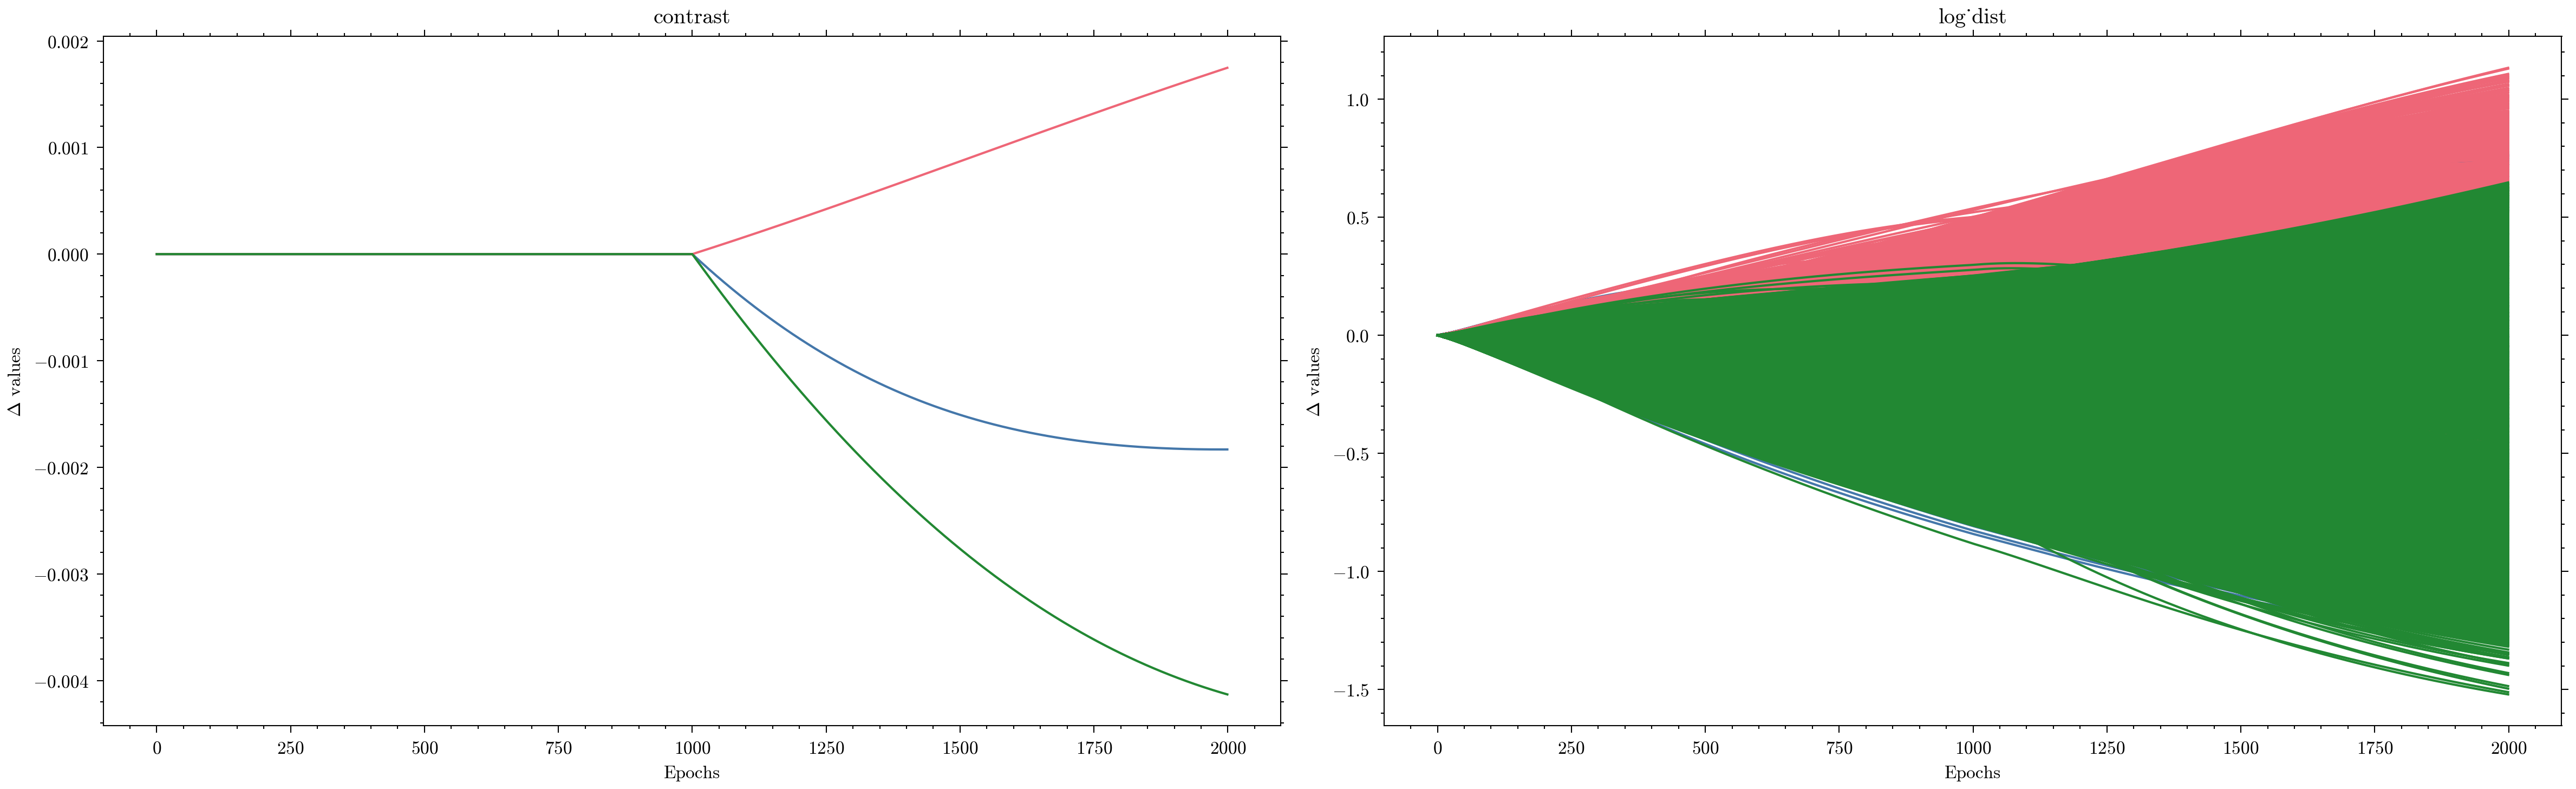

In [25]:
from amigo import plotting

for oi in ois:
    dist = result.model(oi, rotate=False)

    disco_amp, disco_phase = np.split(oi(result.model), 2)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    ax[0].axline((0, 0), slope=1, color="red", linestyle="--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Disco Amplitude")
    ax[0].set_ylabel("Calibrated Disco Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    ax[1].axline((0, 0), slope=1, color="red", linestyle="--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Disco Phase")
    ax[1].set_ylabel("Calibrated Disco Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.5, 0, 0.5]

    fig, ax = plt.subplots(figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist.at[model.size // 2, model.size // 2].set(np.nan),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap=inferno,
        power=0.3,
        vmin=0,
        roll_angle_degrees=-oi.parang,
    )
    ax.scatter([0], [0], marker="*", color="white", s=10)

    fig.colorbar(c0)

    ax.set(
        title=f"PDS 70 - {oi.key}",
        xticks=ticks,
        yticks=ticks,
    )

    plt.tight_layout()
    plt.show()

plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
plotting.plot(result.history)

In [29]:
import equinox as eqx
import optimistix as optx


def BFGS_logdist(
    model,
    exposures,
    reg_args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-4,
    atol=1e-4,
):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exp, reg_args = args

        # input is the log distribution
        log_dist = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exp.get_key("log_dist")] = log_dist
        model = model.set("params", params)

        # calculating loss
        loss, _ = dorito.stats.regularised_loss_fn(model, exp, reg_args)

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exp).sum(), loc=1.0, scale=1e-5
        )

        return loss + sum_prior

    args_out = {}
    sols_out = {}
    for exp in exposures:

        X = model.params["log_dist"][exp.get_key("log_dist")]
        args = (model, exp, reg_args)
        args_out[exp.key] = args

        print("Initial loss:", fun(X, args))
        solver = Solver(rtol=rtol, atol=atol)  # , verbose=frozenset({"loss"}))
        sol = optx.minimise(fun, solver, X, args, throw=False, max_steps=max_steps)
        sols_out[exp.key] = sol

        print("Final loss:", fun(sol.value, args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = model.params
    for exp in ois:
        log_dist = sols_out[exp.key].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist

    return model.set("params", params)


def joint_solve(
    model,
    exposures,
    reg_args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-4,
    atol=1e-4,
):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exps, reg_args = args

        # input is the log distribution
        log_dist = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exps[0].get_key("log_dist")] = log_dist
        model = model.set("params", params)

        # calculating loss
        loss = [
            dorito.stats.regularised_loss_fn(model, exp, reg_args)[0] for exp in exps
        ]
        loss = np.array(loss).mean()

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exps[0]).sum(), loc=1.0, scale=1e-5
        )

        return loss + sum_prior

    args_out = {}
    sols_out = {}

    for filt in ["F380M", "F430M", "F480M"]:

        exps = [oi for oi in exposures if oi.filter == filt]
        for exp in exps:
            print(exp.key)

        if len(exps) == 0:
            print(f"No exposures for filter {filt}, skipping initialisation.")
            continue

        X = model.params["log_dist"][filt]
        _args = (model, exps, reg_args)
        args_out[filt] = _args

        print("Initial loss:", fun(X, _args))
        solver = Solver(rtol=rtol, atol=atol)
        sol = optx.minimise(fun, solver, X, _args, throw=False, max_steps=max_steps)
        sols_out[filt] = sol

        print("Final loss:", fun(sol.value, _args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = {"log_dist": {}, "base_uv": model.params["base_uv"]}
    for exp in ois:
        log_dist = sols_out[exp.filter].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist

    return model.set("params", params)

In [30]:
final_model = result.model


bfgs_model = BFGS_logdist(
    final_model,
    # model,
    ois,
    args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-8,
    atol=1e-8,
)


# bfgs_model = joint_solve(
#     model,
#     # final_model,
#     ois,
#     args,
#     Solver=optx.LevenbergMarquardt,
#     max_steps=2**14,
#     rtol=1e-6,
#     atol=1e-6,
# )

# for oi in ois:
#     sol = sols_out[oi.filter]
#     print(oi.key)
#     print("Final loss:", fun(sol.value, _args))
#     # print(sol.result)

Initial loss: -4134.317045714734
Final loss: -4150.096994501925
1092 586


Initial loss: -3933.598974203025
Final loss: -3998.9645910649856
1017 403


Initial loss: -3018.509591528481
Final loss: -3048.340329940691
1661 1065




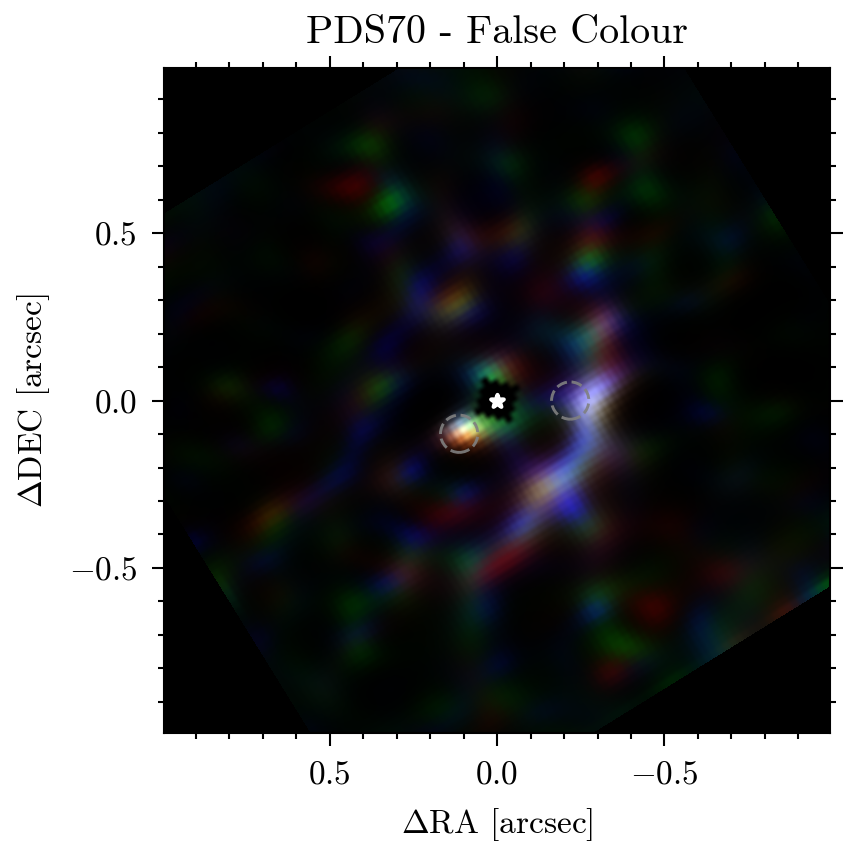

In [75]:
r = bfgs_model.get_distribution(ois[2], with_star=False)
g = bfgs_model.get_distribution(ois[1], with_star=False)
b = bfgs_model.get_distribution(ois[0], with_star=False)

r /= r.max()
g /= g.max()
b /= b.max()
p = 0.8

r = r**p
g = g**p
b = b**p

piccy = np.stack([r, g, b], axis=-1)

fig, ax = plt.subplots(figsize=(3, 3))

c0 = dorito.plotting.plot_result(
    ax,
    piccy,
    pixel_scale=dlu.rad2arcsec(model.pscale_in),
    cmap=inferno,
    power=0.3,
    vmin=0,
    roll_angle_degrees=-oi.parang,
)

seps = 1e-3 * np.array([150.5, 218.4])
pas = np.array([131.2, 270.0])
xs = seps * np.cos(np.radians(pas))
ys = seps * np.sin(np.radians(pas))
ax.scatter(
    ys,
    xs,
    marker="o",
    alpha=0.9,
    s=80,
    facecolors="none",
    edgecolors="grey",
    linestyle="--",
    linewidths=0.7,
)
ax.scatter([0], [0], marker="*", color="white", s=10)
ax.set(
    title=f"PDS70 - False Colour",
    xticks=[-0.5, 0, 0.5],
    yticks=[-0.5, 0, 0.5],
)
plt.tight_layout()
plt.show()

In [12]:
# np.save("files/71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "121pix_os8.npy", bfgs_model.params, allow_pickle=True)

# params = np.load(output_path + "121pix_os8.npy", allow_pickle=True).item()
# bfgs_model = model.set("params", params)

1.0000002044934284
Loss: -2.680e+03


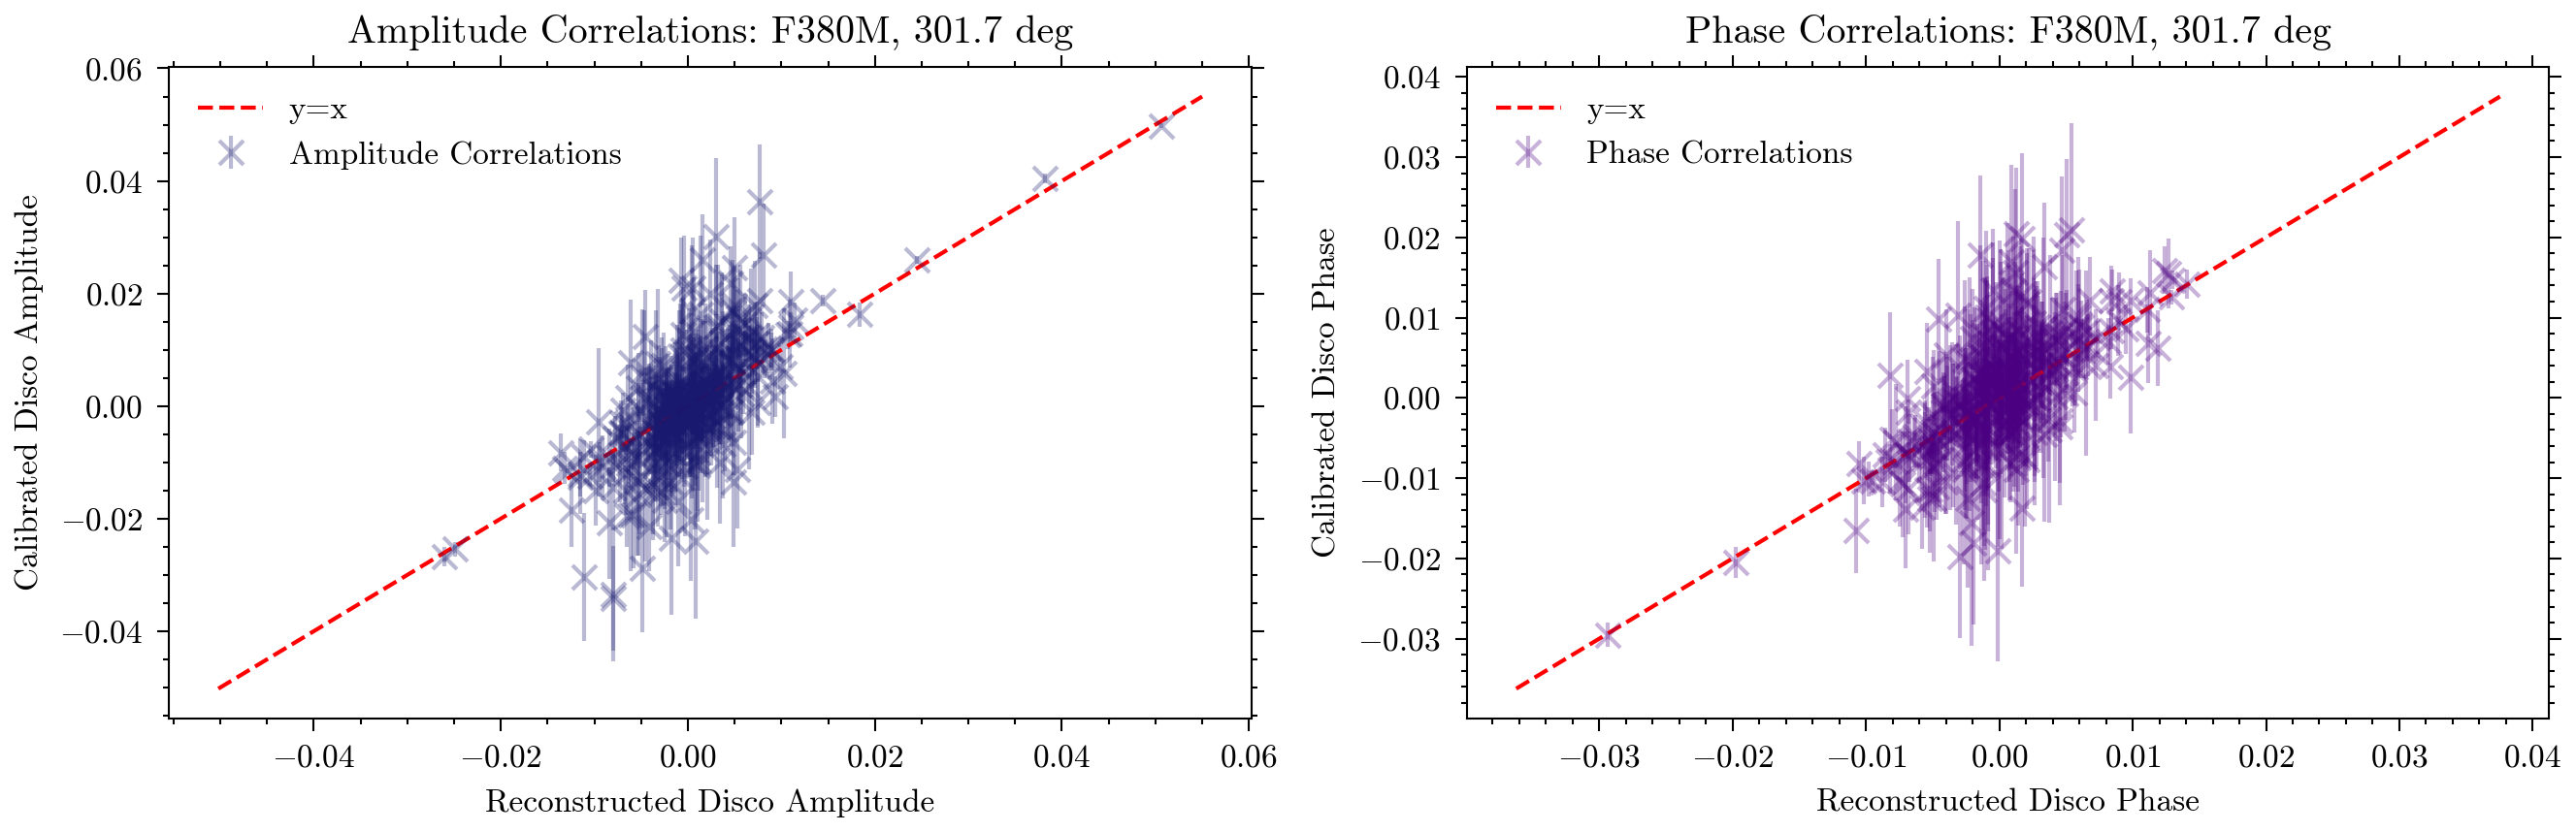

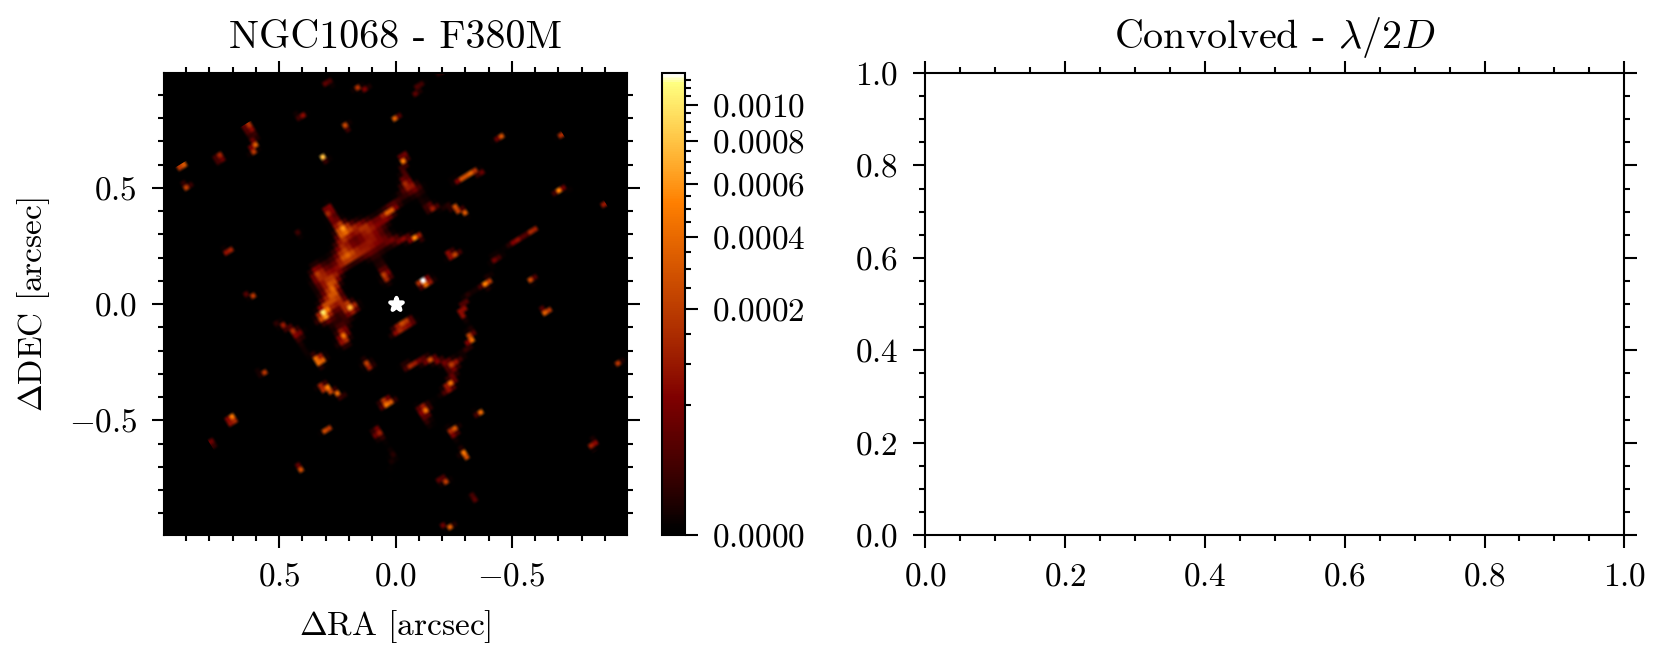

0.9999998019372467
Loss: -2.493e+03


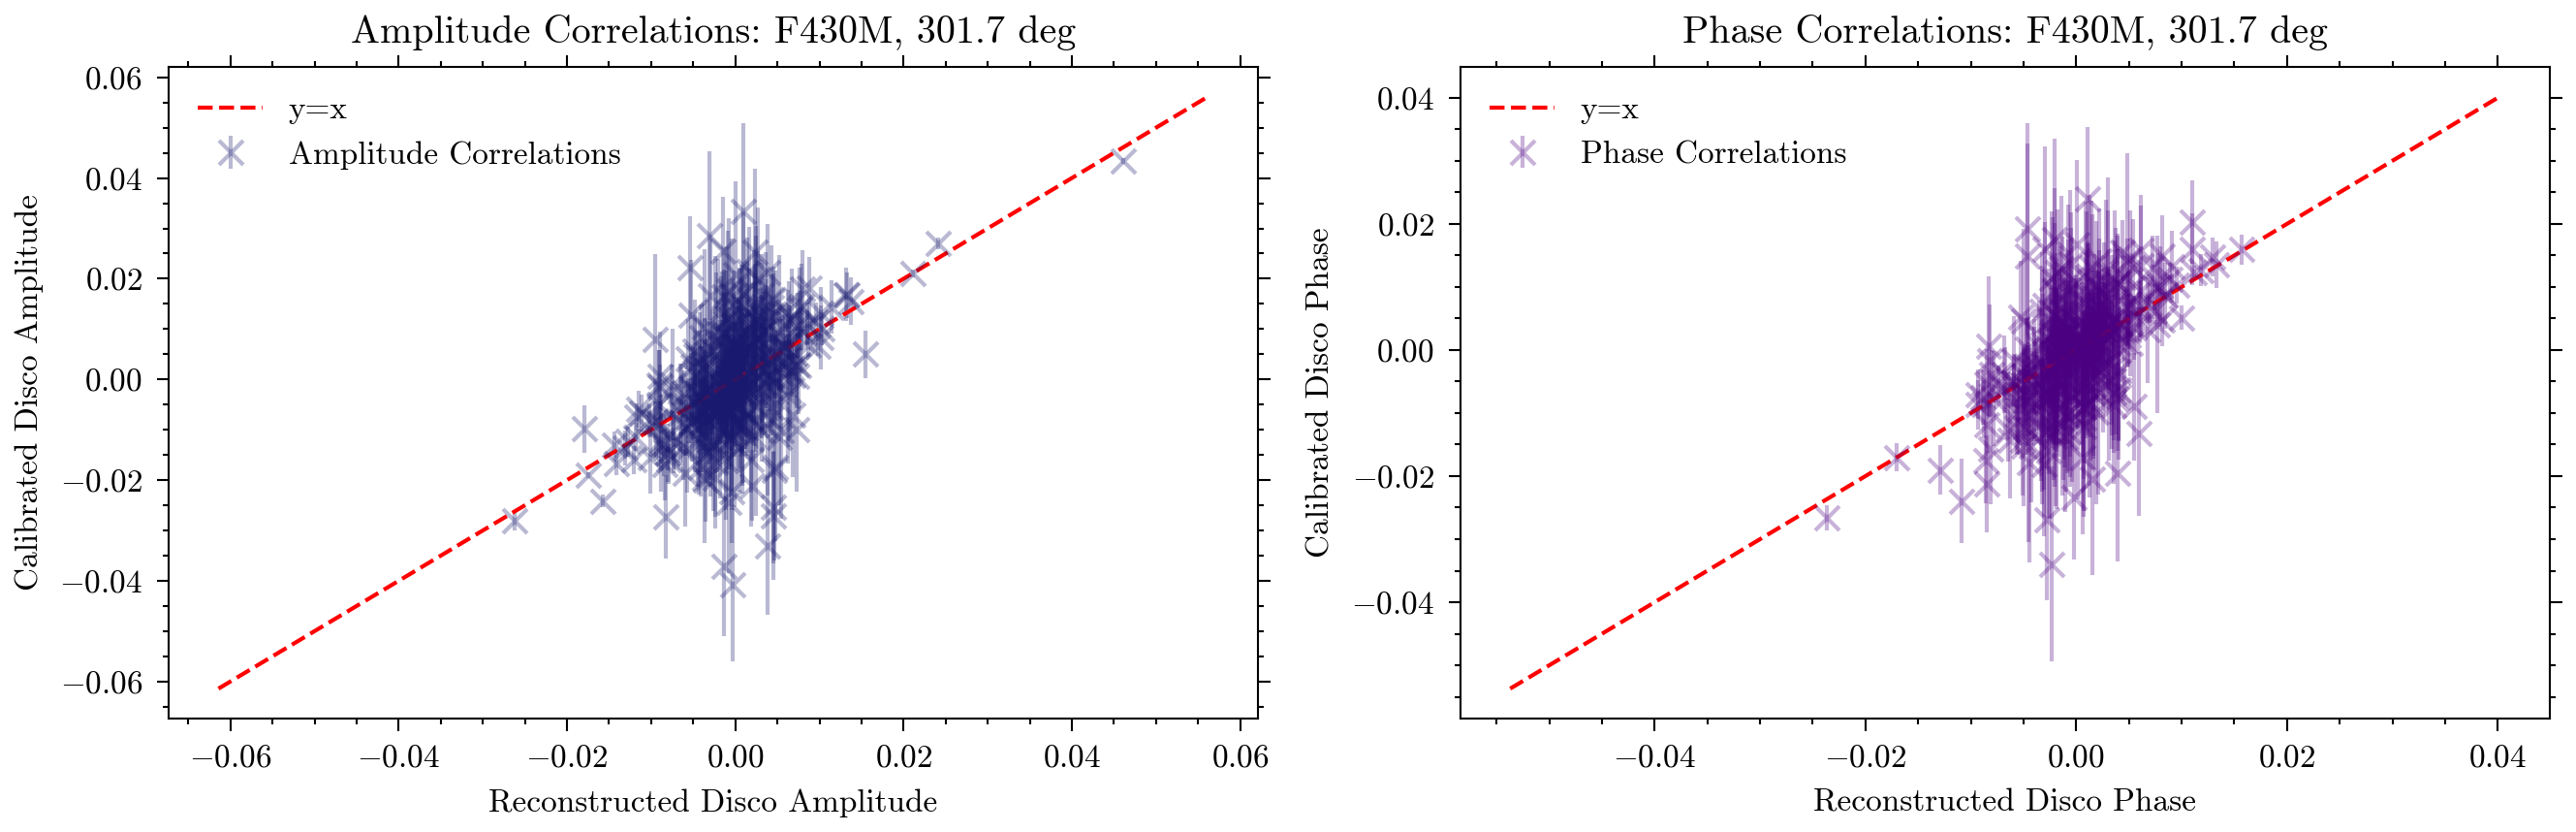

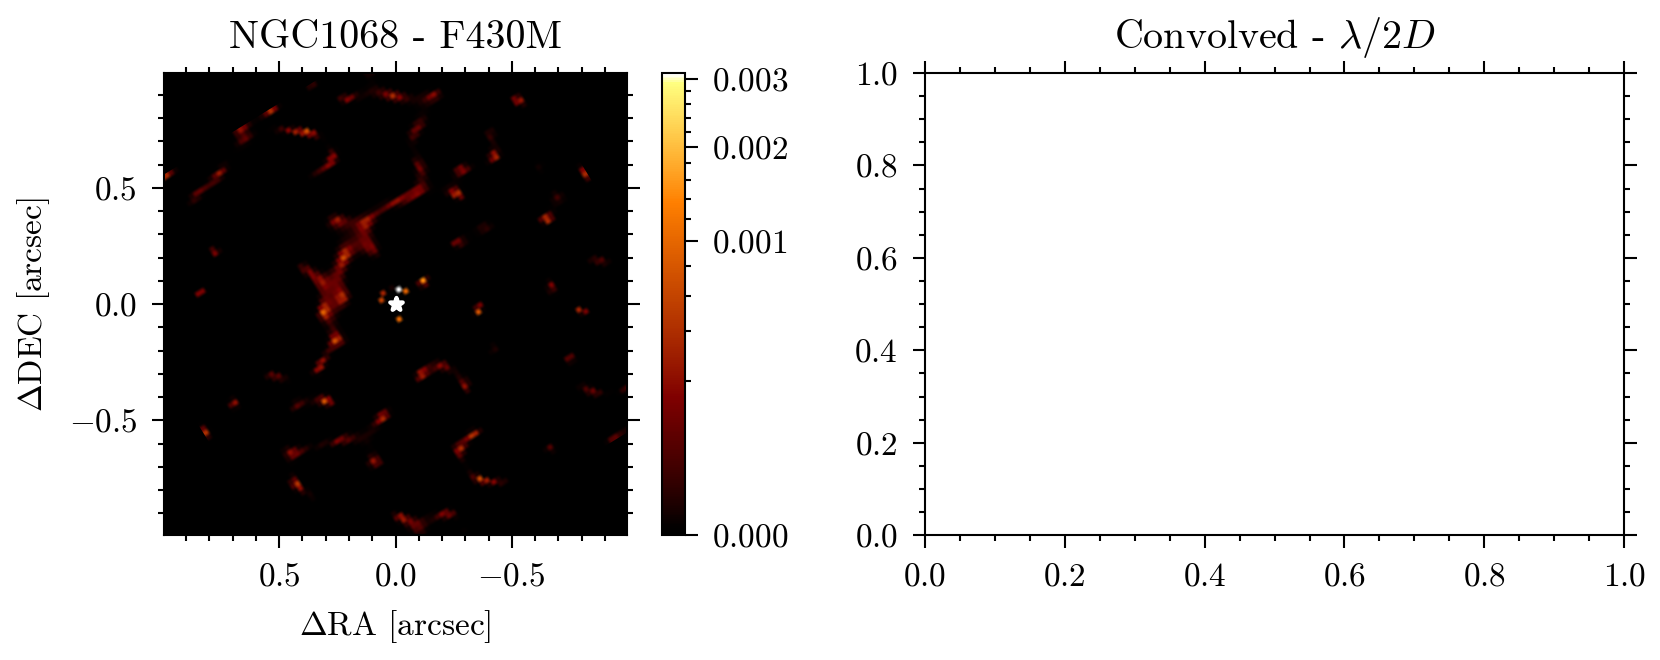

1.0000000240167397
Loss: -1.608e+03


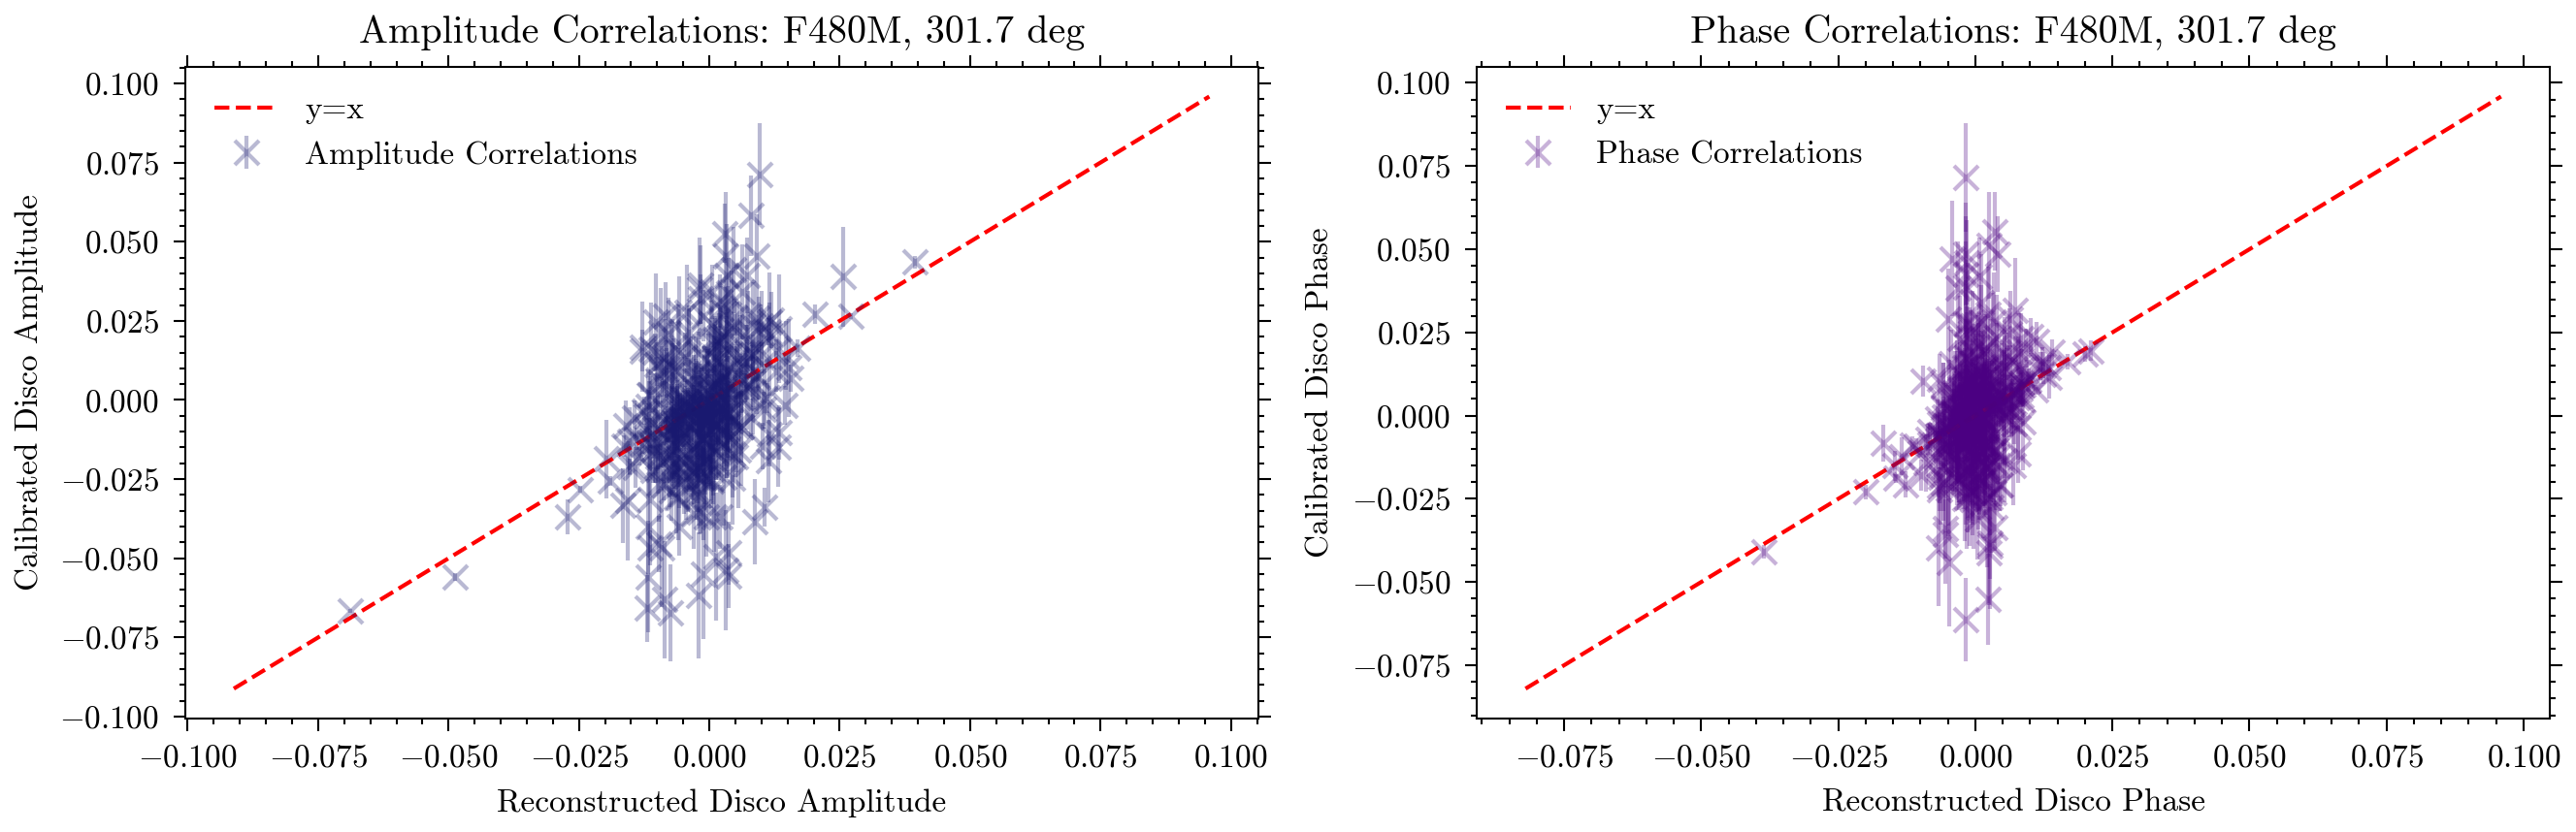

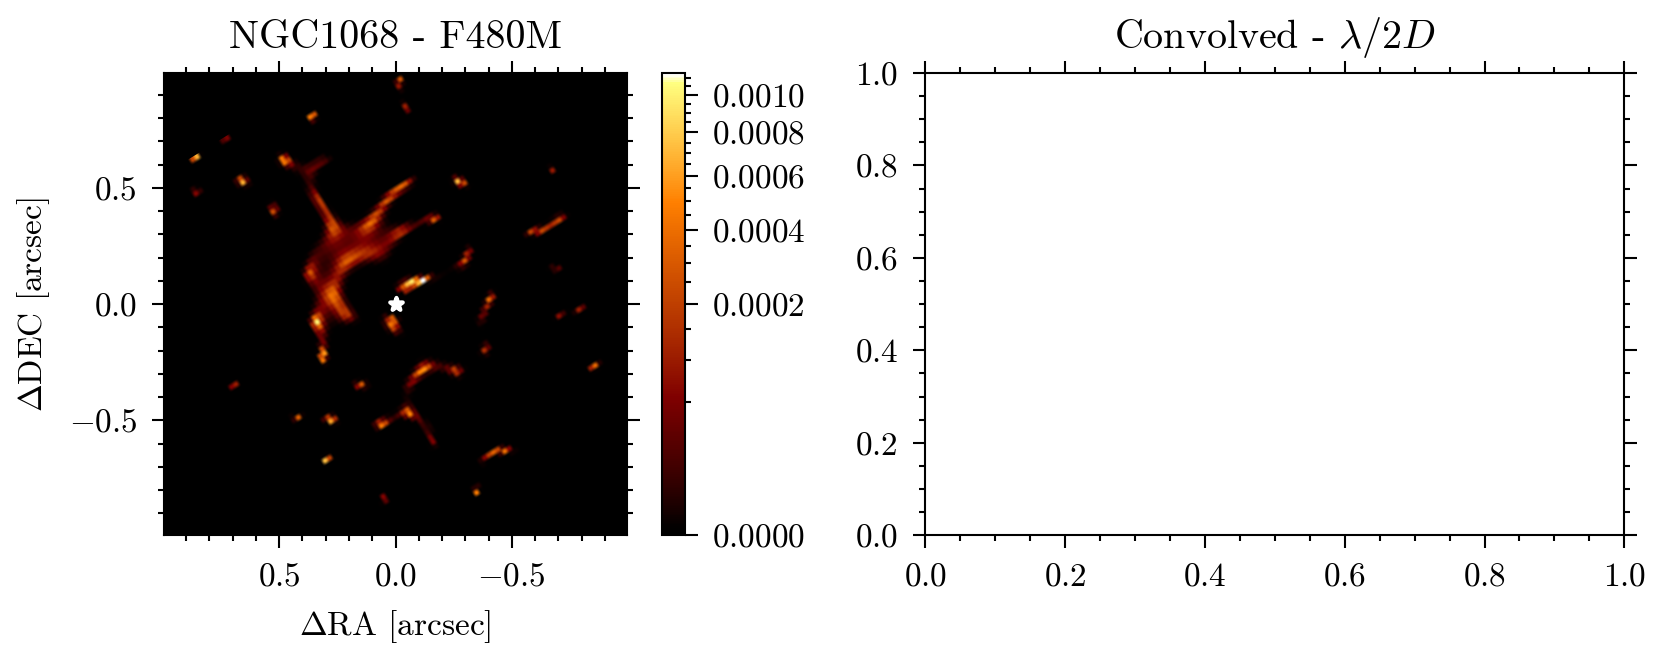

In [13]:
for oi in ois:

    print(bfgs_model.get_distribution(oi).sum())
    # print(phase_centre(bfgs_model, oi))
    loss = dorito.stats.regularised_loss_fn(bfgs_model, oi, args)[0]
    print(f"Loss: {loss:.3e}")

    dist = result.model(oi, rotate=False)
    dist = np.rot90(dist, 2)

    disco_amp, disco_phase = np.split(oi(bfgs_model), 2)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title(f"Amplitude Correlations: {oi.filter}, {oi.parang:.1f} deg")
    ax[0].set_xlabel("Reconstructed Disco Amplitude")
    ax[0].set_ylabel("Calibrated Disco Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title(f"Phase Correlations: {oi.filter}, {oi.parang:.1f} deg")
    ax[1].set_xlabel("Reconstructed Disco Phase")
    ax[1].set_ylabel("Calibrated Disco Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.4, -0.2, 0, 0.2, 0.4]

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax[0],
        dist.at[model.size // 2, model.size // 2].set(np.nan),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_u",
        power=0.4,
        vmin=0,
        roll_angle_degrees=-oi.parang,
    )
    ax[0].scatter([0], [0], marker="*", color="white", s=10)

    # c1 = dorito.plotting.plot_result(
    #     ax[1],
    #     blur_distribution(dist, model, oi, factor=0.5),
    #     pixel_scale=dlu.rad2arcsec(model.pscale_in),
    #     cmap="afmhot_u",
    #     power=0.5,
    #     vmin=None,
    # )
    # fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    # pa = model.params["position_angles"][exp.key]

    ax[0].set_title(
        f"NGC1068 - {oi.filter}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
    )
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    plt.show()

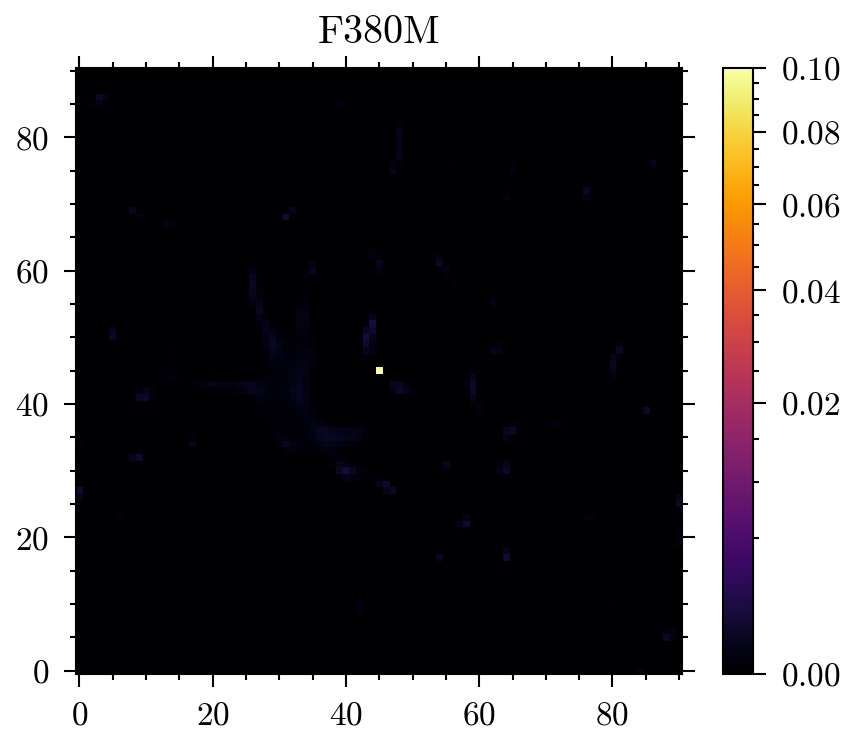

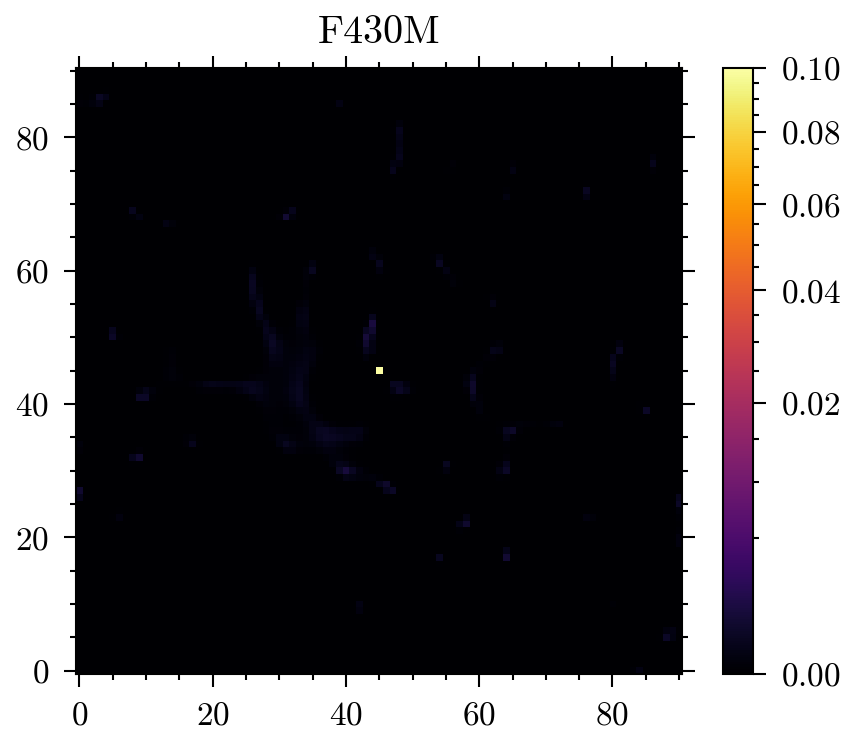

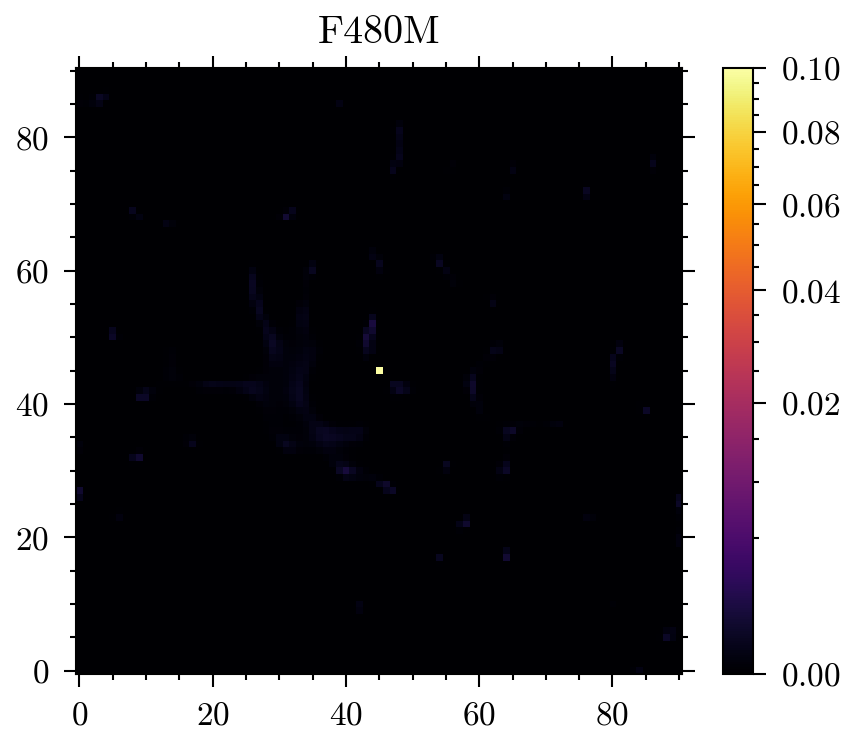

In [14]:
for filt in ["F380M", "F430M", "F480M"]:
    dist = bfgs_model.get_distribution(oi, rotate=False)

    rl_dist = np.clip(dist + 1e-16)
    rl_dist = rl_dist / rl_dist.max()

    rl_dist = np.rot90(rl_dist, 2)
    plt.imshow(rl_dist, norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=1e-1))
    plt.title(filt)
    plt.colorbar()
    plt.show()